## Policy gradient
### REINFORCE ALGORITHM - MONTE CARLO APPROACH
RLDMUU, UniNE 2026, jakub.tluczek@unine.ch

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

First, let's define our policy network $\pi$:

In [8]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_dim_size):
        super(PolicyNetwork, self).__init__()
        # Two fully-connected layers
        self.fc1 = nn.Linear(n_inputs, hidden_dim_size)
        self.fc2 = nn.Linear(hidden_dim_size, n_outputs)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        probs = F.softmax(self.fc2(x), dim=-1)
        log_probs = torch.log(probs)
        return probs, log_probs

In [9]:
# Define the model and the optimizer
policy = PolicyNetwork(n_inputs=4, n_outputs=2, hidden_dim_size=128).to(device)
optimizer = torch.optim.Adam(params=policy.parameters(), lr=1e-3)

In [10]:
# loading the CartPole environment
# https://gymnasium.farama.org/environments/classic_control/cart_pole/
env = gym.make('CartPole-v1')

Final loop:

- generate a trajectory $\tau$ following policy $\pi(\cdot | \cdot, \theta)$
- for each $t$ in $\tau$:
    - $G_t \leftarrow \sum_{k=t+1}^{T} \gamma^{k-t-1} r_k$
    - $\theta \leftarrow \theta + \alpha \gamma^t G_t \nabla \ln \pi (a_t|s_t, \theta)$

with $G_t$ being the discounted reward in future at timestep $t$, $\theta$ meaning policy network parameters and trajectory $tau$ being the set of states, actions and rewards $(s_0, a_0, r_0, s_1, ..., s_T, a_T, r_T)$

In [11]:
NUM_TRAJECTORIES = 2000
MAX_EPISODE_LENGTH = 500
gamma = 0.9
# placeholders for rewards for each episode
rewards = []
losses = []
# iterating through trajectories
for tau in tqdm(range(NUM_TRAJECTORIES)):
    # resetting the environment
    state, info = env.reset()
    # setting done to False for while loop 
    done = False
    # storing trajectory and logπ(a_t|s_t, θ)
    transition_buffer = []
    log_probs = []

    t = 0
    while done == False and t < MAX_EPISODE_LENGTH:
        # Play the episode and collect data
        state_tensor = torch.FloatTensor(state).to(device)
        probs, log_pi = policy(state_tensor)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        next_state, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        transition_buffer.append(reward)
        log_probs.append(log_pi[action])

        state = next_state
        t += 1
    # logging the episode length as a cumulative reward
    rewards.append(t)
    returns = []
    for t_prime in range(t):
        # Compute discounted return G_{t'}
        G = 0
        for i, r in enumerate(transition_buffer[t_prime:]):
            G += (gamma ** i) * r
        returns.append(G)
    # Normalize the returns and perform an update
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    returns = (returns - returns.mean()) / (returns.std() + 1e-9)

    log_probs = torch.stack(log_probs)
    discount_factors = torch.tensor(
        [gamma ** t_prime for t_prime in range(t)], dtype=torch.float32
    ).to(device)
    loss = -(discount_factors * returns * log_probs).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

100%|██████████| 2000/2000 [06:10<00:00,  5.40it/s]


Text(0.5, 1.0, 'REINFORCE cumulative rewards')

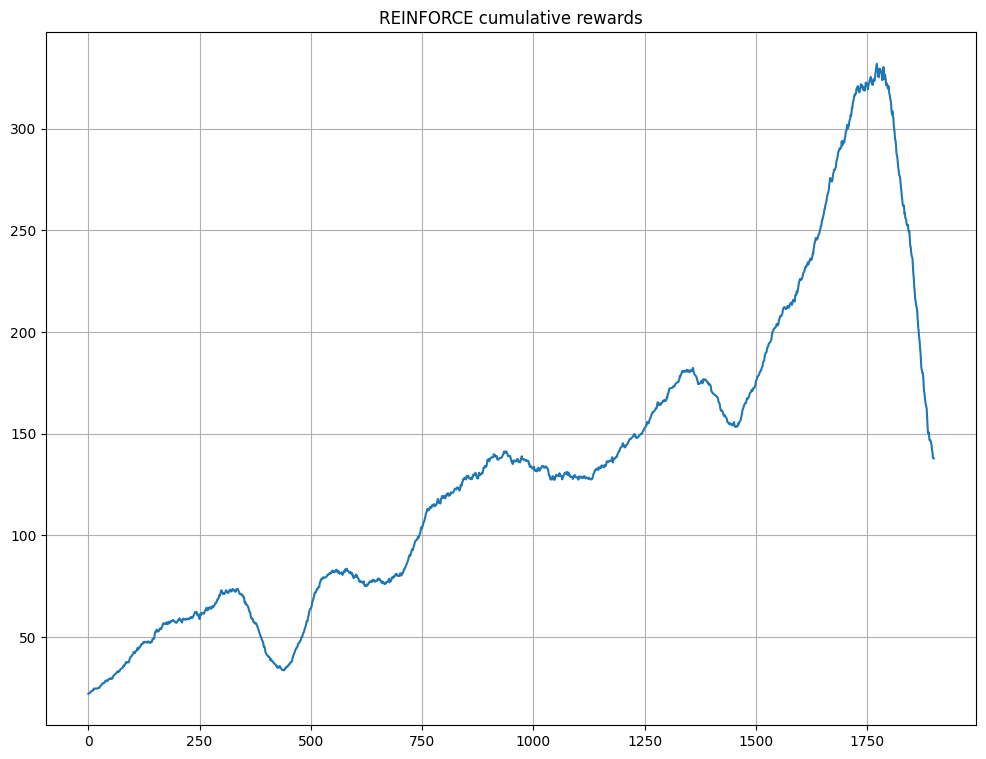

In [ ]:
# plot the results of the training
plt.figure(figsize=(12,9))
plt.plot(running_mean(rewards,100))
plt.grid()
plt.title("REINFORCE cumulative rewards")

In [13]:
import pandas as pd

df = pd.DataFrame(rewards, columns=['reward'])
df.to_csv('REINFORCE.csv')

### Not normalizing returns

In [14]:
# Define the model and the optimizer again
policy = PolicyNetwork(n_inputs=4, n_outputs=2, hidden_dim_size=128).to(device)
optimizer = torch.optim.Adam(params=policy.parameters(), lr=1e-3)

In [15]:
NUM_TRAJECTORIES = 2000
MAX_EPISODE_LENGTH = 500
gamma = 0.9
rewards_non_norm = []
losses_non_norm = []
for tau in tqdm(range(NUM_TRAJECTORIES)):
    state, info = env.reset()
    done = False
    transition_buffer = []
    log_probs = []

    t = 0
    while done == False and t < MAX_EPISODE_LENGTH:
        state_tensor = torch.FloatTensor(state).to(device)
        probs, log_pi = policy(state_tensor)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        next_state, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        transition_buffer.append(reward)
        log_probs.append(log_pi[action])

        state = next_state
        t += 1

    rewards_non_norm.append(t)
    returns = []
    for t_prime in range(t):
        G = 0
        for i, r in enumerate(transition_buffer[t_prime:]):
            G += (gamma ** i) * r
        returns.append(G)

    # No normalization this time
    returns = torch.tensor(returns, dtype=torch.float32).to(device)

    log_probs = torch.stack(log_probs)
    discount_factors = torch.tensor(
        [gamma ** t_prime for t_prime in range(t)], dtype=torch.float32
    ).to(device)
    loss = -(discount_factors * returns * log_probs).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses_non_norm.append(loss.item())

100%|██████████| 2000/2000 [02:53<00:00, 11.50it/s]


Text(0.5, 1.0, 'REINFORCE cumulative rewards')

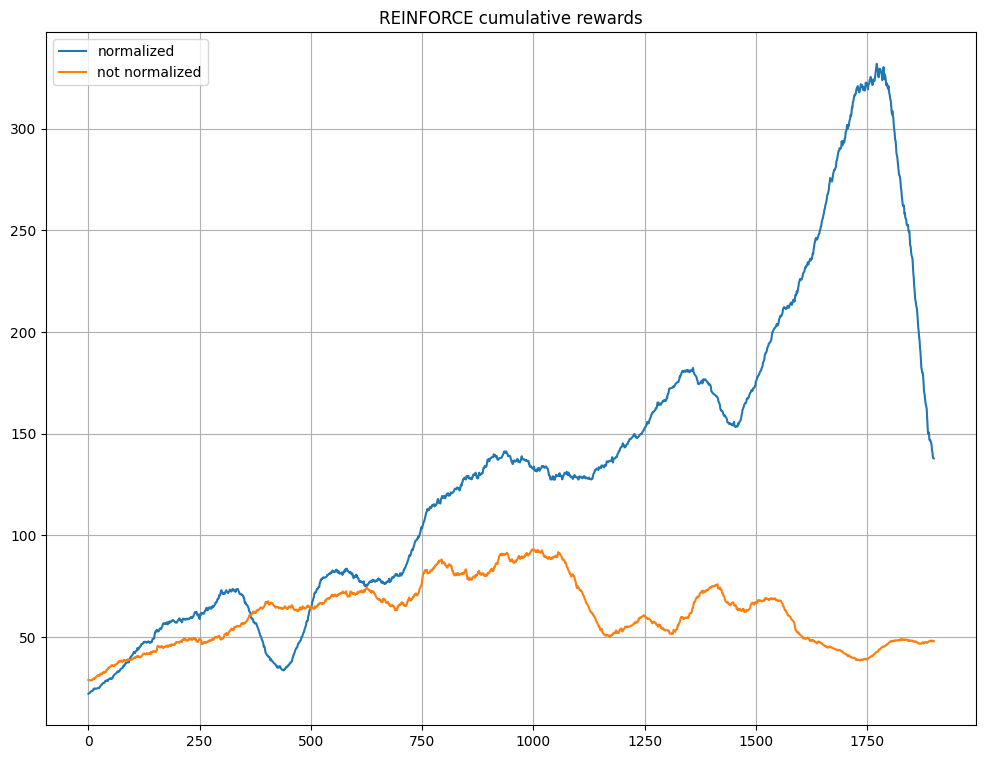

In [16]:
plt.figure(figsize=(12,9))
plt.plot(running_mean(rewards,100), label="normalized")
plt.plot(running_mean(rewards_non_norm, 100), label="not normalized")
plt.grid()
plt.legend()
plt.title("REINFORCE cumulative rewards")

See Chapter 13.3 of Sutton&Barto "Reinforcement Learning"

Additional information about normalizing the discounted rewards:
 - http://karpathy.github.io/2016/05/31/rl/, paragraph *More general advanced functions*